Use de novo data to get enrichments in various categories (AlphaMissense deciles), segregating and non-segregating sites, mutation rate bins etc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy as sc
from scipy.integrate import quad
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from scipy.stats import gmean, linregress, norm, beta, uniform, lognorm, pearsonr, spearmanr, poisson
from scipy.integrate import simpson, cumulative_trapezoid, trapezoid
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.integrate import simpson
from scipy import stats
import glob
import os
import math
import re
import csv
from tqdm import tqdm
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
import pickle
import random
import ast
import json
import Generate_missense

Load data

In [2]:
# Missense file
with open(f"/n/data2/hms/dbmi/sunyaev/lab/pkar/Missense_analysis/final/AlphaMissense.pkl", "rb") as f:
    df_all_variants = pickle.load(f)

print("Done")

# Get LoF data
df_lof = pd.read_csv("../LoF_selection/LoF_s_het.txt.gz", sep="\t", compression="gzip")

Done


In [3]:
df_all_variants = df_all_variants.merge(df_lof[["gene_id", "Posterior_CI10_lower"]], on="gene_id", how="left")

In [4]:
# Remove CES genes
CE_genes = np.array(['ENSG00000078369', 'ENSG00000157933', 'ENSG00000198793', 'ENSG00000117713', 'ENSG00000117400', 'ENSG00000213281', 'ENSG00000143379', 'ENSG00000143622',
                     'ENSG00000135829', 'ENSG00000117139', 'ENSG00000171862', 'ENSG00000108055', 'ENSG00000108061', 'ENSG00000148737', 'ENSG00000066468', 'ENSG00000174775',
                     'ENSG00000184937', 'ENSG00000149480', 'ENSG00000168066', 'ENSG00000175115', 'ENSG00000160584', 'ENSG00000110395', 'ENSG00000111262', 'ENSG00000273079',
                     'ENSG00000133703', 'ENSG00000110844', 'ENSG00000111252', 'ENSG00000179295', 'ENSG00000083642', 'ENSG00000136158', 'ENSG00000176165', 'ENSG00000119596',
                     'ENSG00000179364', 'ENSG00000140262', 'ENSG00000169032', 'ENSG00000137834', 'ENSG00000080603', 'ENSG00000102962', 'ENSG00000174231', 'ENSG00000141510',
                     'ENSG00000196712', 'ENSG00000178691', 'ENSG00000136450', 'ENSG00000170836', 'ENSG00000141376', 'ENSG00000087191', 'ENSG00000161547', 'ENSG00000101752',
                     'ENSG00000152217', 'ENSG00000141646', 'ENSG00000134440', 'ENSG00000256463', 'ENSG00000105204', 'ENSG00000263002', 'ENSG00000160007', 'ENSG00000087088',
                     'ENSG00000063244', 'ENSG00000115758', 'ENSG00000119772', 'ENSG00000213639', 'ENSG00000198369', 'ENSG00000136710', 'ENSG00000115524', 'ENSG00000204217',
                     'ENSG00000036257', 'ENSG00000101266', 'ENSG00000171456', 'ENSG00000244462', 'ENSG00000124233', 'ENSG00000156304', 'ENSG00000159216', 'ENSG00000160201',
                     'ENSG00000099949', 'ENSG00000254709', 'ENSG00000183765', 'ENSG00000099995', 'ENSG00000100393', 'ENSG00000172936', 'ENSG00000168036', 'ENSG00000181555',
                     'ENSG00000169855', 'ENSG00000118007', 'ENSG00000155903', 'ENSG00000159692', 'ENSG00000068078', 'ENSG00000168769', 'ENSG00000113163', 'ENSG00000185129',
                     'ENSG00000145907', 'ENSG00000181163', 'ENSG00000165671', 'ENSG00000204469', 'ENSG00000204435', 'ENSG00000112640', 'ENSG00000171467', 'ENSG00000146247',
                     'ENSG00000164494', 'ENSG00000049618', 'ENSG00000065883', 'ENSG00000146830', 'ENSG00000005483', 'ENSG00000064419', 'ENSG00000157764', 'ENSG00000158941',
                     'ENSG00000164754', 'ENSG00000169249', 'ENSG00000215301', 'ENSG00000126752', 'ENSG00000072501', 'ENSG00000177485', 'ENSG00000101972', 'ENSG00000156531', 
                     'ENSG00000165509', 'ENSG00000167548'])

df_all_variants = df_all_variants[~(df_all_variants["gene_id"].isin(CE_genes))]

In [5]:
# Load the synonymous GnomAD dataset
df_syn = pd.read_csv("../Data/synonymous_data.txt.gz", sep="\t", compression="gzip")

In [6]:
# Kaplanis et al. NDD de novo data mutations
df_NDD = pd.read_csv("/home/prk534/Pop_gen_simulator/selection/Missense/benchmark_files/DNW_clean_syn.txt.gz", sep="\t", compression="gzip")

df_NDD_filtered = df_NDD[~(df_NDD["chromosome"] == "X")]
df_NDD_filtered = df_NDD_filtered.rename(columns={"chromosome": "#CHROM", "position": "POS", "ref": "REF", "alt": "ALT"})

df_NDD_filtered["#CHROM"] = df_NDD_filtered["#CHROM"].astype(int)
df_NDD_filtered["POS"] = df_NDD_filtered["POS"].astype(int)
df_NDD_filtered["REF"] = df_NDD_filtered["REF"].astype(str)
df_NDD_filtered["ALT"] = df_NDD_filtered["ALT"].astype(str)

/tmp/ipykernel_406150/2441758075.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_NDD = pd.read_csv("/home/prk534/Pop_gen_simulator/selection/Missense/benchmark_files/DNW_clean_syn.txt.gz", sep="\t", compression="gzip")


In [7]:
# Group by and count. Count per position and allele in the de novo dataset
df_NDD_counts = (df_NDD_filtered.groupby(['POS', 'REF', 'ALT', '#CHROM']).size().reset_index(name='mutations_1'))
# Merge with synonymous data
df_syn_merged = pd.merge(df_syn[["#CHROM", "POS", "REF", "ALT", "MR", "gene_id", "allele_count", "allele_number"]], df_NDD_counts, on=["#CHROM", "POS", "REF", "ALT"], how="left")  # or "inner" depending on whether you want to retain all rows in df1 or only matches
df_syn_merged["mutations_1"] = df_syn_merged["mutations_1"].fillna(0)
# Find scaling
scaling = df_syn_merged["mutations_1"].sum() / df_syn_merged["MR"].sum()

In [8]:
# Step 3: Merge with missense dataframe
df_all_variants_full = df_all_variants.merge(df_NDD_counts, on=["#CHROM", "POS", "REF", "ALT"], how="left")
# Step 4: Fill NaN values (i.e., no match) with 0
df_all_variants_full["mutations_1"] = df_all_variants_full["mutations_1"].fillna(0)
# Get scaled expected mutation count
df_all_variants_full["Scaled_MR_1"] = df_all_variants_full["MR"] * scaling

Find the observed / expected enrichment in NDD trios. The enrichment is calculated for top 3 deciles based on AlphaMissense and within each decile we divide the genes based on LoF selection values

In [9]:
def oe_by_shet_bin_nonoverlap(
    df,
    s_col="Posterior_CI10_lower",
    score_col="AlphaMissense",
    score_percentile_bins=[(0.7, 0.8), (0.8, 0.9), (0.9, 1.0)],
    obs_col="mutations_1",
    exp_col="Scaled_MR_1",
    n_bins=5
):
    d = df[[s_col, score_col, obs_col, exp_col]].dropna().copy()

    # percentile rank of score_col
    d["score_pct"] = d[score_col].rank(method="average", pct=True)

    # LoF bins
    d["s_bin"] = pd.qcut(d[s_col], q=n_bins, labels=False, duplicates="drop")

    rows = []

    for lo, hi in score_percentile_bins:
        if hi == 1.0:
            score_mask = (d["score_pct"] >= lo) & (d["score_pct"] <= hi)
        else:
            score_mask = (d["score_pct"] >= lo) & (d["score_pct"] < hi)

        d_bin = d[score_mask].copy()

        for b in sorted(d["s_bin"].unique()):
            sub = d[d["s_bin"] == b]
            sub_sel = d_bin[d_bin["s_bin"] == b]

            O = float(sub_sel[obs_col].sum())
            E = float(sub_sel[exp_col].sum())

            s_median = float(sub[s_col].median())

            if E > 0:
                oe = O / E
                se = np.sqrt(O) / E if O > 0 else 0.0
            else:
                oe = np.nan
                se = np.nan

            rows.append({
                "score_bin": f"{int(lo*100)}-{int(hi*100)}%",
                "s_bin": b,
                "s_median": s_median,
                "OE": oe,
                "SE": se,
                "O": O,
                "E": E
            })

    return pd.DataFrame(rows).sort_values(["score_bin", "s_bin"]).reset_index(drop=True)

In [19]:
def plot_oe_nonoverlap(res_df, score_col="AlphaMissense", save_fig=None):
    
    sns.set_style("white")

    fig, ax = plt.subplots(figsize=(8.2, 5.4))

    score_bins = sorted(res_df["score_bin"].unique())
    s_bins = sorted(res_df["s_bin"].unique())

    palette = sns.color_palette("deep", len(s_bins))

    n_score = len(score_bins)
    n_s = len(s_bins)

    # main x positions = score bins
    x = np.arange(n_score)
    offsets = np.linspace(-0.28, 0.28, n_s)

    #--- 1. Scientific Notation for Legend (LaTeX Style) ---
    def format_sci(v):
        # Converts 0.0003 to 3.0 \times 10^{-4}
        s = f"{v:.0e}"
        base, exp = s.split('e')
        return f"${float(base):.0f} \\times 10^{{{int(exp)}}}$"

    s_labels = (res_df.groupby("s_bin")["s_median"].median()
                .sort_index()
                .map(format_sci)
                .tolist())

    for offset, s_bin, color, s_lab in zip(offsets, s_bins, palette, s_labels):
        r = res_df[res_df["s_bin"] == s_bin].sort_values("score_bin")

        ax.errorbar(
            x + offset,
            r["OE"],
            yerr=r["SE"],
            fmt="o",
            linestyle="none",
        
            # --- Marker (primary signal) ---
            markersize=15,
            markerfacecolor=color,
            markeredgecolor="white",
            markeredgewidth=1.2,
        
            # --- Error bars (secondary) ---
            ecolor=color,
            elinewidth=2,
            capsize=8,
        
            # --- Layering ---
            zorder=3,
        
            label=s_lab
        )

    ax.axhline(1.0, linestyle=(0, (5, 5)), color="black", linewidth=0.8, zorder=0)

    ax.set_xticks(x)
    ax.set_xticklabels(score_bins, fontsize=14)
    ax.set_xlabel(f"{score_col} percentile", fontsize=20)
    ax.set_ylabel("Observed / Expected", fontsize=20)

    ax.tick_params(axis="y", labelsize=14)
    ax.legend(frameon=False, fontsize=18, title="LoF selection coefficient", title_fontsize=18)

    plt.tight_layout()

    if save_fig is not None:
        plt.savefig(save_fig, bbox_inches="tight", dpi=300)

    plt.show()

In [10]:
res = oe_by_shet_bin_nonoverlap(df_all_variants_full, n_bins=5)

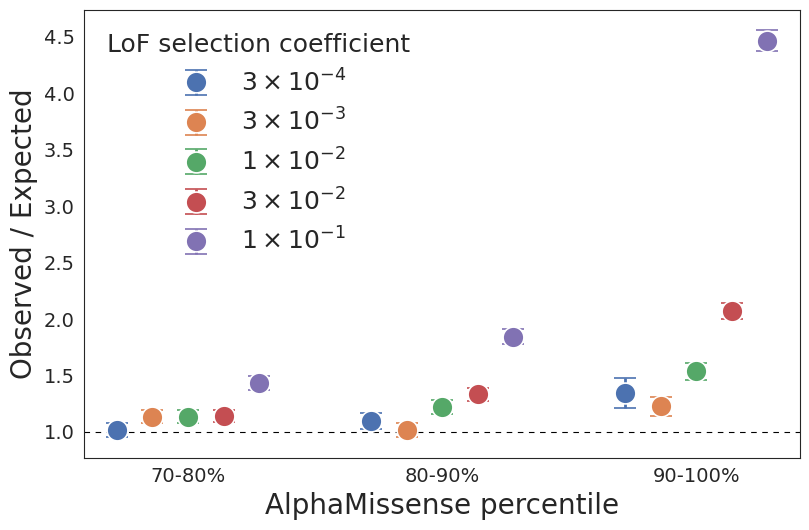

In [20]:
plot_oe_nonoverlap(res, save_fig="../Figures/OE_AM.svg")

Enrichment in top 50% pathogenic variants based on AlphaMissense. We divide these variants into 4 categories based on mutation rates and allele counts

In [26]:
# Same for missense with AM > = 0.9 and AM<= 0.1
def plot_enrichment(df, filename = None, fig_name = None):

    # --- Binning allele_count ---
    allele_labels = ["0", "≥1"]
    df_plot = df.copy()
    df_plot["allele_cat"] = pd.cut(
        df_plot["allele_count"],
        bins=[-0.5, 0.5, np.inf],
        labels=allele_labels
    )
    
    # --- Binning MR into 3 categories ---
    bins = [-np.inf, 1, np.inf]
    mu_labels = ["Low mutation rate", "High mutation rate"]
    df_plot["mu_bin"] = pd.cut(df_plot["MR"], bins=bins, labels=mu_labels, right=False)
    
    # --- Aggregate ---
    grouped = df_plot.groupby(
        ["mu_bin", "allele_cat"],
        observed=True
    ).agg(
        mutations_sum=("mutations_1", "sum"),
        scaled_sum=("Scaled_MR_1", "sum")
    )
    grouped["ratio"] = grouped["mutations_sum"] / grouped["scaled_sum"]
    grouped["err"] = np.sqrt(grouped["mutations_sum"]) / grouped["scaled_sum"]
    grouped = grouped.reset_index()

    if filename is not None:
        grouped.to_csv(filename, index=False)
    
    # --- Pivot for plotting ---
    pivot = grouped.pivot(index="mu_bin", columns="allele_cat", values="ratio")
    errors = grouped.pivot(index="mu_bin", columns="allele_cat", values="err")
    
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8.2, 5.4))
    
    x = np.arange(len(mu_labels))  # positions for μ-rate bins
    width = 0.25                   # bar width
    colors = ["skyblue", "salmon", "seagreen"]

    for i, allele_cat in enumerate(allele_labels):
        ax.bar(
            x + i * width,
            pivot[allele_cat],
            width=width,
            color=colors[i],
            edgecolor="white",
            linewidth=0.8,
            label=f"Allele count {allele_cat}",
            zorder=2
        )
    
        ax.errorbar(
            x + i * width,
            pivot[allele_cat],
            yerr=errors[allele_cat],
            fmt="none",
            ecolor="black",
            elinewidth=1.0,
            capsize=2.5,
            capthick=1.0,
            zorder=3
        )
    
    # --- Formatting ---
    group_center = x + width * (len(allele_labels) - 1) / 2
    ax.set_xticks(group_center)
    ax.set_xticklabels(mu_labels, fontsize=15)
    
    ax.tick_params(axis="both", which="major", labelsize=14, length=4, width=1)
    ax.tick_params(axis="both", which="minor", length=2.5, width=0.8)
    
    ax.set_xlabel("Mutation type", fontsize=20)
    ax.set_ylabel("Observed / expected", fontsize=20)
    
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.7, zorder=1)
    
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.25, zorder=0)
    ax.set_axisbelow(True)
    
    ax.legend(
        title="Allele count",
        frameon=False,
        fontsize=18,
        title_fontsize=18
    )
    
    plt.tight_layout()
    if fig_name is not None:
        plt.savefig(fig_name, bbox_inches="tight", dpi=300)
    plt.show()


In [25]:
df_all_variants_filt = df_all_variants_full[["AlphaMissense", "Scaled_MR_1", "MR",
                                             "allele_count", "mutations_1"]].dropna().copy()

# percentile rank of score_col
df_all_variants_filt["score_pct"] = df_all_variants_filt["AlphaMissense"].rank(method="average", pct=True)
df_all_variants_filt

,AlphaMissense,Scaled_MR_1,MR,allele_count,mutations_1,score_pct
0,0.6602,0.000108,0.030,0.0,0.0,0.710988
1,0.8999,0.000183,0.051,0.0,0.0,0.825623
2,0.6065,0.000072,0.020,0.0,0.0,0.689357
3,0.9725,0.000108,0.030,0.0,0.0,0.897541
4,0.8753,0.000262,0.073,5.0,0.0,0.809871
...,...,...,...,...,...,...
58550651,0.9760,0.000222,0.062,1.0,0.0,0.903527
58550652,0.6725,0.000183,0.051,0.0,0.0,0.715973
58550653,0.4607,0.000108,0.030,0.0,0.0,0.626537
58550654,0.9424,0.000183,0.051,0.0,0.0,0.860141


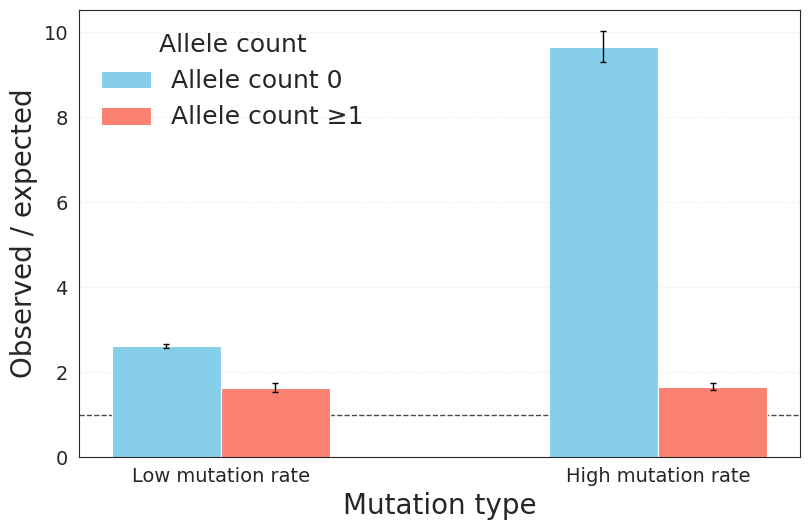

In [ ]:
plot_enrichment(df_all_variants_filt[df_all_variants_filt["score_pct"]>0.5], fig_name="../Figures/OE_AC_mu_AMg50.svg")